#Project Scope
This project will develop a Restaurant Performance Risk and Opportunity Model focused on U.S. restaurant locations. The initial public-data analysis will use U.S.-based restaurant records available in the Yelp Open Dataset, with later validation against available Denny’s U.S. business intelligence data. Additional nationwide market-context variables will be incorporated using free public sources such as USDA and U.S. Census data.

##Project Title:Restaurant Performance Risk and Opportunity Model

###Business Problem:
Restaurant operators need a practical way to identify locations that may be at higher performance risk or have opportunity for improvement based on customer reputation, market context, and operational performance indicators.
Initial Model Scope:
###Industry: Restaurants only
Geography: United States only
Initial modeling sample: U.S. restaurant businesses contained in the Yelp Open Dataset
Later validation: Denny’s U.S. performance or business intelligence data
Final output: Restaurant risk/opportunity scoring model and business recommendations
####1. Target Geography
Set your target geography as:
United States only, limited initially to the U.S. restaurant locations represented in the Yelp Open Dataset.
Later, when you bring in Denny’s data, you can compare or validate model patterns using a broader U.S. operating footprint.
####2. Free and Easily Available Data Sources
For your timeline, do not try to collect too many datasets. Your best approach is:
Priority	Dataset	Purpose	Week 1 Decision
Required	Yelp Open Dataset	Restaurant locations, categories, ratings, review counts, review text	Already acquired
Recommended	USDA Food Environment Atlas	County-level restaurant and market environment context nationwide	Add later
Recommended	U.S. Census ACS	Population, median income, poverty and demographic market variables	Add later
Later Validation	Denny’s BI Data	Validate risk/opportunity patterns against enterprise KPIs

# Task
The objective is to prepare the foundation for a Restaurant Performance Risk and Opportunity Model using the Yelp Open Dataset. This involves locating and loading the business data, filtering for restaurants specifically within the United States, and performing an initial exploratory analysis to understand the geographic distribution of these establishments across U.S. states. The final output will be a cleaned subset of data ready for risk/opportunity scoring.

## Locate and Load Yelp Business Data

### Subtask:
Identify the Yelp business JSON file and load it into a pandas DataFrame.


# 01 Yelp Data Acquisition and Filtering

## 1. Project Setup
## 2. Load Yelp Business Data
## 3. Filter to U.S. Restaurants
## 4. Save Clean Business Dataset
## 5. Initial EDA
## 6. Prepare Business IDs for Review Filtering

In [ ]:
#2 Load Yelp Business Data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import os

business_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/yelp_academic_dataset_business.json"

df_business = pd.read_json(business_path, lines=True)

print(df_business.shape)
df_business.head()

(150346, 14)


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [ ]:
# 3 Filter to US resturants
us_states = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY",
    "DC"
]

df_restaurants = df_business[
    df_business["categories"].notna()
    & df_business["categories"].str.contains("Restaurants", case=False, na=False)
    & df_business["state"].isin(us_states)
].copy()

print("Raw business records:", len(df_business))
print("Filtered U.S. restaurants:", len(df_restaurants))
print("States represented:", df_restaurants["state"].nunique())

df_restaurants.head()

Raw business records: 150346
Filtered U.S. restaurants: 49857
States represented: 17


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
5,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
8,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None
9,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsAttire': ''casual'', 'Restaurants...","Ice Cream & Frozen Yogurt, Fast Food, Burgers,...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-21:0', '..."
11,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'Alcohol': ''none'', 'OutdoorSeating': 'None'...","Vietnamese, Food, Restaurants, Food Trucks","{'Monday': '11:0-14:0', 'Tuesday': '11:0-14:0'..."


In [ ]:
#4 Save Clean business file data set
processed_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurants.csv"

os.makedirs(os.path.dirname(processed_path), exist_ok=True)

df_restaurants.to_csv(processed_path, index=False)

print("Saved:", processed_path)

Saved: /content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurants.csv


In [ ]:
#4b Save Business ID
restaurant_ids_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurant_business_ids.csv"

df_restaurants[["business_id"]].to_csv(restaurant_ids_path, index=False)

print("Saved:", restaurant_ids_path)

Saved: /content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurant_business_ids.csv


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#cleaned and filtered reviews to US based resturant business Dataset
import pandas as pd

business_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurants.csv"
reviews_path = "/content/drive/MyDrive/Classroom/CAPESTONE 6999/processed/yelp_us_restaurant_reviews_sampled_100_per_business.parquet"

df_business = pd.read_csv(business_path)
df_reviews = pd.read_parquet(reviews_path)

print("Business shape:", df_business.shape)
print("Reviews shape:", df_reviews.shape)

df_reviews.head()

Business shape: (49857, 14)
Reviews shape: (2405356, 9)


,review_id,business_id,user_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,XQfwVwDr-v0ZS3_CbbE5Xw,mh_-eMZ6K5RLWhZyISBhwA,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,saUsX_uimxRlCVr67Z4Jig,YjUWPpI6HXG530lwP-fb2A,8g_iMtfSiwikVnbP2etR0A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
2,AqPFMleE6RsU23_auESxiA,kxX2SOes4o-D3ZQBkiMRfA,_7bHUi9Uuf5__HHc_Q8guQ,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
3,Sx8TMOWLNuJBWer-0pcmoA,e4Vwtrqf-wpJfwesgvdgxQ,bcjbaE6dDog4jkNY91ncLQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
4,JrIxlS1TzJ-iCu79ul40cQ,04UD14gamNjLY0IDYVhHJg,eUta8W_HdHMXPzLBBZhL1A,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31


In [ ]:
matched_reviews = df_reviews["business_id"].isin(df_business["business_id"]).sum()
match_rate = matched_reviews / len(df_reviews)

print("Total reviews:", len(df_reviews))
print("Matched reviews:", matched_reviews)
print("Match rate:", round(match_rate * 100, 2), "%")

Total reviews: 2405356
Matched reviews: 2405356
Match rate: 100.0 %


In [ ]:
print("Business missing values:")
display(df_business.isna().sum())

print("Review missing values:")
display(df_reviews.isna().sum())

Business missing values:


,0
business_id,0
name,0
address,437
city,0
state,0
postal_code,19
latitude,0
longitude,0
stars,0
review_count,0


Review missing values:


,0
review_id,0
business_id,0
user_id,0
stars,0
useful,0
funny,0
cool,0
text,0
date,0


In [ ]:
df_business.info()
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49857 entries, 0 to 49856
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   business_id   49857 non-null  object 
 1   name          49857 non-null  object 
 2   address       49420 non-null  object 
 3   city          49857 non-null  object 
 4   state         49857 non-null  object 
 5   postal_code   49838 non-null  float64
 6   latitude      49857 non-null  float64
 7   longitude     49857 non-null  float64
 8   stars         49857 non-null  float64
 9   review_count  49857 non-null  int64  
 10  is_open       49857 non-null  int64  
 11  attributes    49347 non-null  object 
 12  categories    49857 non-null  object 
 13  hours         42973 non-null  object 
dtypes: float64(4), int64(2), object(8)
memory usage: 5.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2405356 entries, 0 to 2405355
Data columns (total 9 columns):
 #   Column       Dtype  
---

## 5 Business-Level EDA

This section reviews the restaurant business dataset after filtering to U.S.-based restaurant businesses. The goal is to understand the number of restaurants, states represented, rating distribution, review count distribution, and open versus closed status.

In [ ]:
print("Number of restaurants:", len(df_business))
print("Number of states:", df_business["state"].nunique())

display(df_business["state"].value_counts().head(15))
display(df_business["stars"].value_counts().sort_index())
display(df_business["is_open"].value_counts())

Number of restaurants: 49857
Number of states: 17


,count
state,
PA,12641
FL,8731
TN,4352
MO,4247
IN,4150
LA,3640
NJ,3341
AZ,2671
NV,1673


,count
stars,
1.0,236
1.5,1441
2.0,2792
2.5,4593
3.0,7254
3.5,11212
4.0,12796
4.5,8026
5.0,1507


,count
is_open,
1,33252
0,16605


## EDA Charts

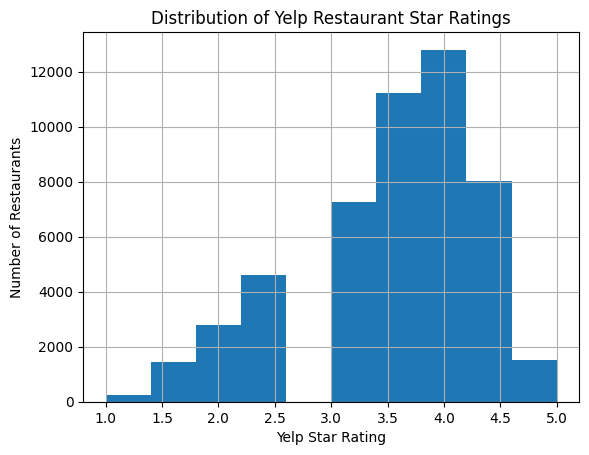

In [ ]:
import matplotlib.pyplot as plt

df_business["stars"].hist(bins=10)
plt.title("Distribution of Yelp Restaurant Star Ratings")
plt.xlabel("Yelp Star Rating")
plt.ylabel("Number of Restaurants")
plt.show()

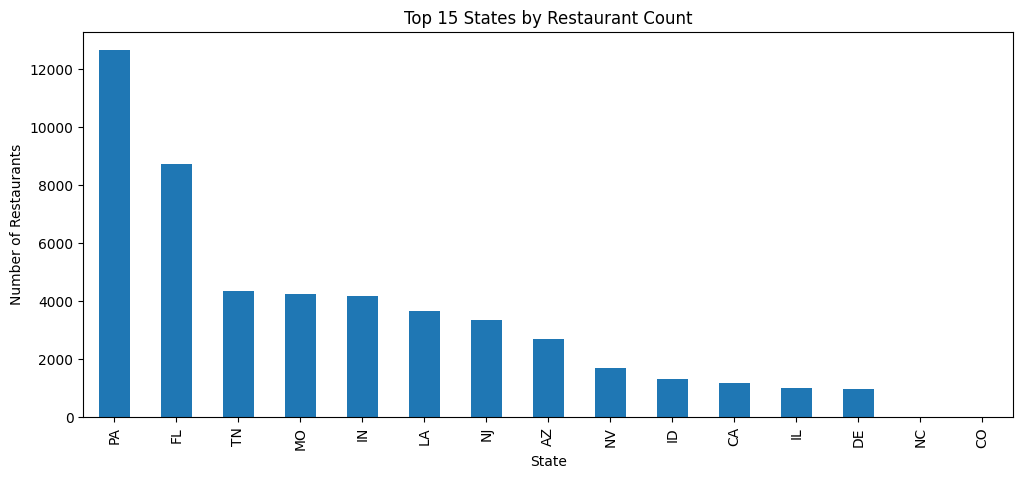

In [ ]:
df_business["state"].value_counts().head(15).plot(kind="bar", figsize=(12,5))
plt.title("Top 15 States by Restaurant Count")
plt.xlabel("State")
plt.ylabel("Number of Restaurants")
plt.show()

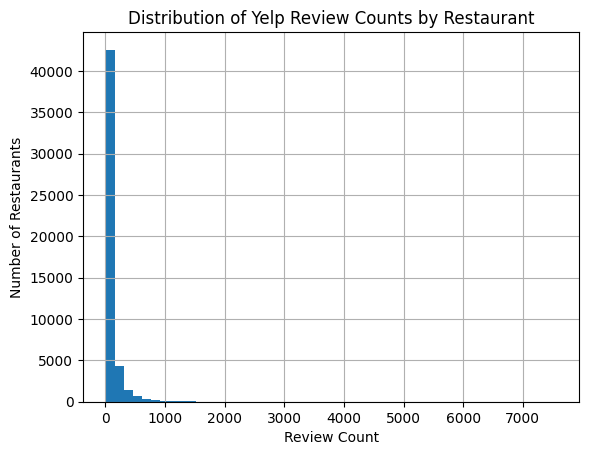

In [ ]:
df_business["review_count"].hist(bins=50)
plt.title("Distribution of Yelp Review Counts by Restaurant")
plt.xlabel("Review Count")
plt.ylabel("Number of Restaurants")
plt.show()

## Review Level EDA

In [ ]:
print("Number of reviews:", len(df_reviews))
print("Businesses with reviews:", df_reviews["business_id"].nunique())

display(df_reviews["stars"].value_counts().sort_index())

Number of reviews: 2405356
Businesses with reviews: 49857


,count
stars,
1.0,349732
2.0,222591
3.0,278064
4.0,556215
5.0,998754


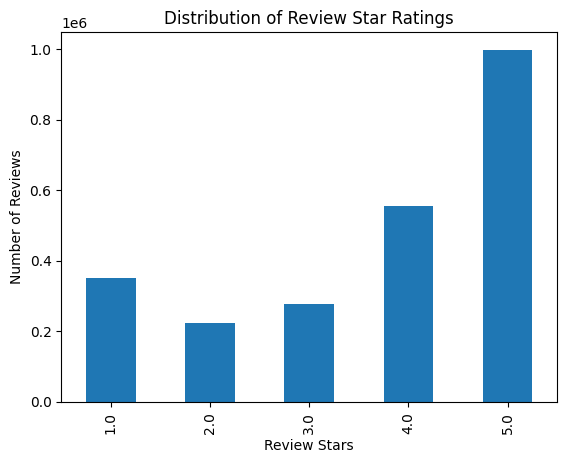

In [ ]:
df_reviews["stars"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Star Ratings")
plt.xlabel("Review Stars")
plt.ylabel("Number of Reviews")
plt.show()

## Data Preparation Summary

At this stage, the Yelp business dataset was loaded, filtered to U.S.-based restaurant businesses, and saved as a clean restaurant business file. A separate business ID file was also prepared and used outside of Colab to filter the large Yelp review JSON file locally in VS Code. Because the raw review file was too large for Google Drive and Colab, the review file was processed locally, filtered to restaurant businesses only, sampled to a maximum of 100 reviews per business, and saved as a Parquet file for efficient loading.

Final prepared files:
- `yelp_us_restaurants.csv`
- `yelp_us_restaurant_reviews_sampled_100_per_business.parquet`

These files will be used for the next phase of EDA, feature engineering, sentiment/risk labeling, and model preparation.

In [ ]:
print("Final Dataset Validation")
print("-" * 40)

print("Business records:", df_business.shape)
print("Review records:", df_reviews.shape)

print("Unique business IDs in business file:", df_business["business_id"].nunique())
print("Unique business IDs in reviews file:", df_reviews["business_id"].nunique())

matched_reviews = df_reviews["business_id"].isin(df_business["business_id"]).sum()
match_rate = matched_reviews / len(df_reviews)

print("Matched reviews:", matched_reviews)
print("Review match rate:", round(match_rate * 100, 2), "%")

Final Dataset Validation
----------------------------------------
Business records: (49857, 14)
Review records: (2405356, 9)
Unique business IDs in business file: 49857
Unique business IDs in reviews file: 49857
Matched reviews: 2405356
Review match rate: 100.0 %
